<a href="https://colab.research.google.com/github/nopedamn/Fake_news_detector/blob/main/Fake_News_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string


In [15]:
data_fake=pd.read_csv('Fake.csv')
data_true=pd.read_csv('True.csv')

In [16]:
from google.colab import drive
drive.mount('drive')

Drive already mounted at drive; to attempt to forcibly remount, call drive.mount("drive", force_remount=True).


In [17]:
data_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [18]:
data_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [20]:
data_fake["class"]=0
data_true['class']=1

In [21]:
data_fake.shape,data_true.shape

((23481, 5), (21417, 5))

In [22]:
data_fake_manual_testing = data_fake.tail(10)
data_fake.drop(data_fake_manual_testing.index, axis=0, inplace=True)

data_true_manual_testing = data_true.tail(10)
data_true.drop(data_true_manual_testing.index, axis=0, inplace=True)

In [23]:
data_merge = pd.concat([data_fake, data_true], axis=0)
display(data_merge.head())

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


Next, we'll drop columns that are not relevant for the classification task, such as 'title', 'subject', and 'date'. The 'text' column will be our primary feature.

In [24]:
data = data_merge.drop(['title', 'subject', 'date'], axis=1)
display(data.head())

,text,class
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [25]:
data_fake.shape,data_true.shape

((23471, 5), (21407, 5))

In [26]:
data_fake_manual_testing['class']=0
data_true_manual_testing['class']=1

/tmp/ipykernel_3034/1676563180.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_fake_manual_testing['class']=0
/tmp/ipykernel_3034/1676563180.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_true_manual_testing['class']=1


In [27]:
data_fake_manual_testing.head(10)

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [28]:
data_merge = pd.concat([data_fake, data_true], axis =0 )
data_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [29]:
data_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [31]:
data = data_merge.drop(['title', 'subject','date'], axis = 1)

In [32]:
data.isnull().sum()

,0
text,0
class,0


In [33]:
data= data.sample(frac=1)

In [34]:
data.head()

,text,class
4626,WASHINGTON (Reuters) - President Donald Trump’...,1
5757,"BET EL, West Bank (Reuters) - For many in the ...",1
16252,The Washington Post reported that higher ups i...,0
7206,BERLIN (Reuters) - German Chancellor Angela Me...,1
5339,Donald Trump sat down with for an interview wi...,0


### Class Distribution
Let's visualize the distribution of `Fake` vs. `True` news in our combined dataset.

/tmp/ipykernel_3034/919525110.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=data, palette='viridis')


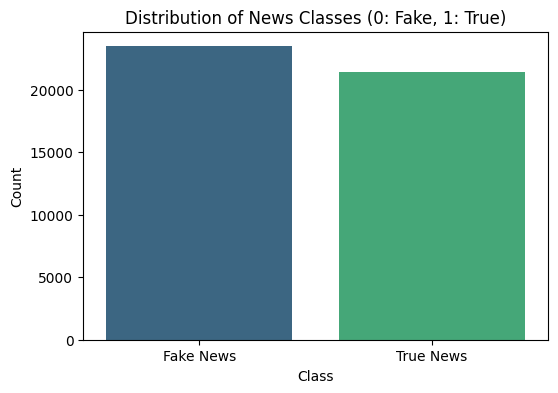

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=data, palette='viridis')
plt.title('Distribution of News Classes (0: Fake, 1: True)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake News', 'True News'])
plt.show()

In [38]:
data.reset_index(inplace= True)
data.drop(['index'], axis=1,inplace=True)

In [39]:
data.columns

Index(['text', 'class'], dtype='object')

In [40]:
data.head()

,text,class
0,WASHINGTON (Reuters) - President Donald Trump’...,1
1,"BET EL, West Bank (Reuters) - For many in the ...",1
2,The Washington Post reported that higher ups i...,0
3,BERLIN (Reuters) - German Chancellor Angela Me...,1
4,Donald Trump sat down with for an interview wi...,0


In [41]:
def wordopt(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_3034/2411212894.py:3: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
/tmp/ipykernel_3034/2411212894.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
/tmp/ipykernel_3034/2411212894.py:9: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


In [43]:
data['text']= data['text'].apply(wordopt)

In [44]:
x = data['text']
y = data['class']

In [45]:
z_train, z_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(z_train)
xv_test = vectorization.transform(z_test)

In [48]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(xv_train,y_train)

LogisticRegression()

In [49]:
pred_lr=LR.predict(xv_test)

In [50]:
LR.score(xv_test, y_test)

0.9860071301247771

In [51]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5918
           1       0.98      0.99      0.99      5302

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



### Confusion Matrix for Logistic Regression
Let's visualize the performance of the Logistic Regression model using a confusion matrix.

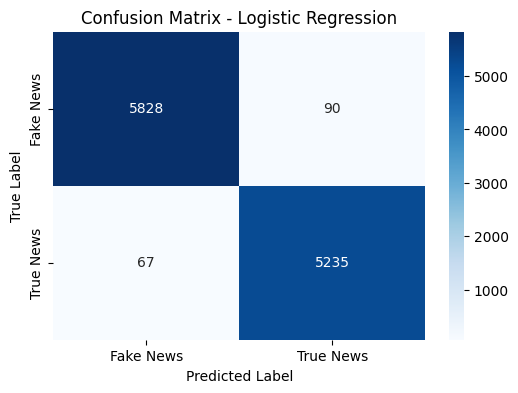

In [52]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [53]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

DecisionTreeClassifier()

In [54]:
pred_dt = DT.predict(xv_test)

In [55]:
DT.score(xv_test, y_test)

0.9948306595365419

In [56]:
print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5918
           1       1.00      0.99      0.99      5302

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



### Confusion Matrix for Decision Tree
Now, let's visualize the performance of the Decision Tree model using a confusion matrix.

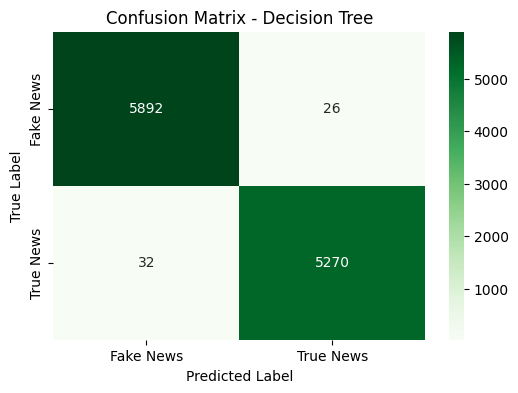

In [57]:
cm_dt = confusion_matrix(y_test, pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [58]:
print([x for x in globals() if 'train'in x.lower()])

['train_test_split', 'z_train', 'y_train', 'xv_train']


In [59]:
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier(random_state=0)
GBC.fit(xv_train, y_train)

GradientBoostingClassifier(random_state=0)

In [61]:
predict_gbc = GBC.predict(xv_test)

In [62]:
GBC.score(xv_test, y_test)

0.9942959001782531

In [63]:
print(classification_report(y_test, predict_gbc))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5918
           1       0.99      1.00      0.99      5302

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



### Confusion Matrix for Gradient Boosting Classifier
Next, we visualize the performance of the Gradient Boosting Classifier using a confusion matrix.

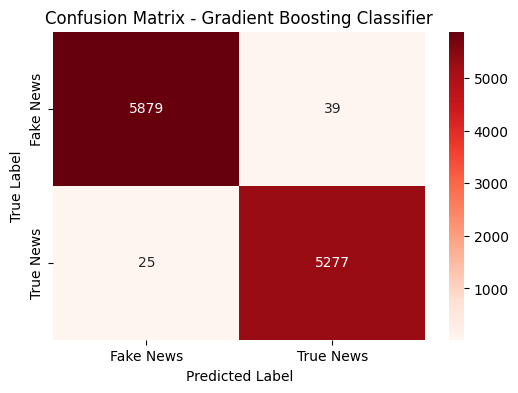

In [64]:
cm_gbc = confusion_matrix(y_test, predict_gbc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Reds', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [65]:
from sklearn.ensemble import RandomForestClassifier
RFC = RandomForestClassifier(random_state=0)
RFC.fit(xv_train, y_train)

RandomForestClassifier(random_state=0)

In [66]:
predict_rfc = RFC.predict(xv_test)

In [67]:
RFC.score(xv_test, y_test)

0.990909090909091

In [68]:
print(classification_report(y_test, predict_rfc))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5918
           1       0.99      0.99      0.99      5302

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



### Confusion Matrix for Random Forest Classifier
Finally, let's look at the confusion matrix for the Random Forest Classifier.

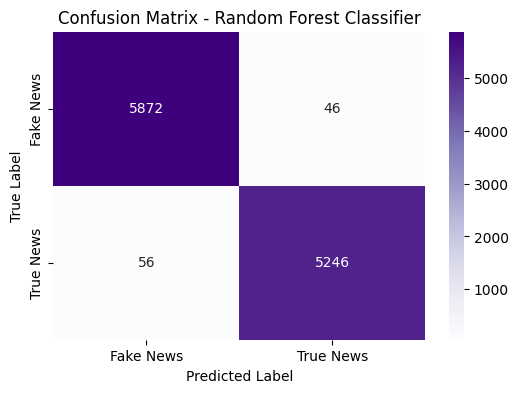

In [69]:
cm_rfc = confusion_matrix(y_test, predict_rfc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Purples', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [70]:
def output_label(n):
    if n == 0:
        return "Fake News"
    elif n == 1:
        return "Not A Fake News"

def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"]= new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    pred_LR = LR.predict(new_xv_test)
    pred_DT = DT.predict(new_xv_test)
    pred_GBC = GBC.predict(new_xv_test)

    return print("\n\nLR Prediction: {} \nDT Prediction: {} \nGBC Prediction: {}".format(output_label(pred_LR[0]),
                                                                                                              output_label(pred_DT[0]),
                                                                                                              output_label(pred_GBC[0])))

In [71]:
news = input()
manual_testing(news)

WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal courts, the Pentagon said on Friday, after President Donald Trump’s administration decided not to appeal rulings that blocked his transgender ban. Two federal appeals courts, one in Washington and one in Virginia, last week rejected the administration’s request to put on hold orders by lower court judges requiring the military to begin accepting transgender recruits on Jan. 1. A Justice Department official said the administration will not challenge those rulings. “The Department of Defense has announced that it will be releasing an independent study of these issues in the coming weeks. So rather than litigate this interim appeal before that occurs, the administration has decided to wait for DOD’s study and will continue to defend the president’s lawful authority in District Court in the meantime,” the official said, speaking on condition o

In [72]:
data_fake.shape,data_true.shape

((23471, 5), (21407, 5))

In [74]:
news = input()
manual_testing(news)

WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal courts, the Pentagon said on Friday, after President Donald Trump’s administration decided not to appeal rulings that blocked his transgender ban. Two federal appeals courts, one in Washington and one in Virginia, last week rejected the administration’s request to put on hold orders by lower court judges requiring the military to begin accepting transgender recruits on Jan. 1. A Justice Department official said the administration will not challenge those rulings. “The Department of Defense has announced that it will be releasing an independent study of these issues in the coming weeks. So rather than litigate this interim appeal before that occurs, the administration has decided to wait for DOD’s study and will continue to defend the president’s lawful authority in District Court in the meantime,” the official said, speaking on condition o

In [ ]:
import pickle

pickle.dump(vectorization, open("vectorizer.pkl", "wb"))
pickle.dump(LR, open("lr_model.pkl", "wb"))
pickle.dump(DT, open("dt_model.pkl", "wb"))
pickle.dump(GBC, open("gbc_model.pkl", "wb"))
pickle.dump(RFC, open("rfc_model.pkl", "wb"))

print("All models saved successfully!")